# Week 13: ndarray and Tensor Operations

## Mini Project: Manual vs. NumPy Matrix Operations

This notebook explores:
- **ndarray and Tensor Fundamentals**: Understanding NumPy ndarrays and tensor concepts
- **Tensor Operations**: Broadcasting, indexing, and manipulation
- **Manual Implementation**: Matrix operations from scratch
- **NumPy Implementation**: Optimized ndarray operations
- **Performance Comparison**: Benchmarking and analysis

---

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple
import time
import sys
import os

# Add parent directory to path to import custom modules
sys.path.insert(0, '/Users/maksimvialykh/github/tensor-operations')

from manual_matrix import Matrix, eye as manual_eye, zeros as manual_zeros
from numpy_matrix import NumpyMatrix, eye as numpy_eye, zeros as numpy_zeros, random_matrix

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!
NumPy version: 2.4.1


## 2. Understanding ndarrays and Tensors

### What is an ndarray?
- **n-dimensional array** from NumPy
- Homogeneous collection of elements (same data type)
- Foundation for numerical computing in Python
- Backed by C arrays for performance

In [2]:
# Creating ndarrays of different dimensions
print("=" * 60)
print("Creating ndarrays of different dimensions")
print("=" * 60)

# 1D array (vector)
vector = np.array([1, 2, 3, 4, 5])
print(f"\n1D Array (Vector):")
print(f"  Data: {vector}")
print(f"  Shape: {vector.shape}")
print(f"  Ndim: {vector.ndim}")
print(f"  Data type: {vector.dtype}")
print(f"  Size: {vector.size}")

# 2D array (matrix)
matrix_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"\n2D Array (Matrix):")
print(f"  Data:\n{matrix_2d}")
print(f"  Shape: {matrix_2d.shape}")
print(f"  Ndim: {matrix_2d.ndim}")

# 3D array (tensor)
tensor_3d = np.arange(24).reshape(2, 3, 4)
print(f"\n3D Array (Tensor):")
print(f"  Shape: {tensor_3d.shape}")
print(f"  Ndim: {tensor_3d.ndim}")
print(f"  First 2D slice:\n{tensor_3d[0]}")

# Array properties
print(f"\nArray Properties:")
print(f"  Itemsize (bytes per element): {matrix_2d.itemsize}")
print(f"  Nbytes (total bytes): {matrix_2d.nbytes}")
print(f"  Memory layout (C-contiguous): {matrix_2d.flags['C_CONTIGUOUS']}")
print(f"  Memory layout (F-contiguous): {matrix_2d.flags['F_CONTIGUOUS']}")

Creating ndarrays of different dimensions

1D Array (Vector):
  Data: [1 2 3 4 5]
  Shape: (5,)
  Ndim: 1
  Data type: int64
  Size: 5

2D Array (Matrix):
  Data:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
  Shape: (3, 3)
  Ndim: 2

3D Array (Tensor):
  Shape: (2, 3, 4)
  Ndim: 3
  First 2D slice:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Array Properties:
  Itemsize (bytes per element): 8
  Nbytes (total bytes): 72
  Memory layout (C-contiguous): True
  Memory layout (F-contiguous): False


## 3. Basic ndarray Operations

In [ ]:
print("=" * 60)
print("Basic ndarray Operations")
print("=" * 60)

A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[7, 8, 9], [10, 11, 12]])

print(f"\nArray A:\n{A}")
print(f"\nArray B:\n{B}")

# Element-wise operations
print(f"\nElement-wise Addition (A + B):\n{A + B}")
print(f"\nElement-wise Multiplication (A * B):\n{A * B}")
print(f"\nScalar operations (A * 2):\n{A * 2}")

# Reshaping
print(f"\nReshape A from {A.shape} to (3, 2):\n{A.reshape(3, 2)}")
print(f"Flatten A:\n{A.flatten()}")

# Transposition
print(f"\nTranspose of A:\n{A.T}")

# Slicing and indexing
print(f"\nSlicing operations:")
print(f"  A[0, :] (first row): {A[0, :]}")
print(f"  A[:, 1] (second column): {A[:, 1]}")
print(f"  A[0:1, 1:3] (submatrix): {A[0:1, 1:3]}")

# Boolean indexing
print(f"\nBoolean indexing (A > 3):\n{A[A > 3]}")

# Broadcasting demonstration
print("\n" + "=" * 60)
print("Broadcasting Demonstration")
print("=" * 60)

matrix = np.array([[1, 2, 3], [4, 5, 6]])
vector = np.array([1, 10, 100])

print(f"\nMatrix shape: {matrix.shape}")
print(f"Vector shape: {vector.shape}")
print(f"\nMatrix:\n{matrix}")
print(f"\nVector: {vector}")
print(f"\nMatrix + Vector (broadcasting):\n{matrix + vector}")

## 4. Tensor Operations

In [ ]:
print("=" * 60)
print("Tensor Operations and Advanced Linear Algebra")
print("=" * 60)

# Create sample matrices
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[1, 2], [3, 4], [5, 6]])

print(f"\nMatrix A (shape {A.shape}):\n{A}")
print(f"\nMatrix B (shape {B.shape}):\n{B}")

# Matrix multiplication
print(f"\nMatrix Multiplication (A @ B) shape {A.shape} @ {B.shape}:")
result = A @ B
print(f"Result shape: {result.shape}")
print(f"Result:\n{result}")

# Square matrices for more operations
M = np.array([[4, 7], [2, 6]])
print(f"\nSquare Matrix M:\n{M}")

# Determinant
det_M = np.linalg.det(M)
print(f"Determinant of M: {det_M}")

# Inverse
M_inv = np.linalg.inv(M)
print(f"\nInverse of M:\n{M_inv}")

# Verify: M @ M_inv should be identity
identity_check = M @ M_inv
print(f"\nVerification (M @ M_inv):\n{np.round(identity_check, 10)}")

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(M)
print(f"\nEigenvalues of M: {eigenvalues}")
print(f"\nEigenvectors of M:\n{eigenvectors}")

# Trace (sum of diagonal)
trace_M = np.trace(M)
print(f"\nTrace of M: {trace_M}")

# Rank
rank_M = np.linalg.matrix_rank(M)
print(f"Rank of M: {rank_M}")

# Singular Value Decomposition
U, s, Vt = np.linalg.svd(M)
print(f"\nSingular Value Decomposition:")
print(f"  Singular values: {s}")
print(f"  U shape: {U.shape}")
print(f"  V^T shape: {Vt.shape}")

## 5. Manual Matrix Operations Implementation

In [3]:
print("=" * 60)
print("Manual Matrix Implementation Examples")
print("=" * 60)

# Create matrices using manual implementation
data_A = [[1, 2, 3], [4, 5, 6]]
data_B = [[1, 2], [3, 4], [5, 6]]

manual_A = Matrix(data_A)
manual_B = Matrix(data_B)

print(f"\nManual Matrix A ({manual_A.rows}x{manual_A.cols}):")
print(manual_A)

print(f"\nManual Matrix B ({manual_B.rows}x{manual_B.cols}):")
print(manual_B)

# Addition
print(f"\nManual Addition Test:")
manual_C = Matrix([[1, 2], [3, 4]])
manual_D = Matrix([[5, 6], [7, 8]])
manual_sum = manual_C + manual_D
print(f"C + D =\n{manual_sum}")

# Transpose
print(f"\nManual Transpose:")
print(f"A.transpose() =\n{manual_A.transpose()}")

# Matrix multiplication
print(f"\nManual Matrix Multiplication:")
result_manual = manual_A @ manual_B
print(f"A @ B =\n{result_manual}")

# Determinant and Inverse for small square matrix
print(f"\nManual Determinant and Inverse:")
manual_M = Matrix([[4, 7], [2, 6]])
print(f"Matrix M:\n{manual_M}")

det_M = manual_M.determinant()
print(f"\nDeterminant of M: {det_M}")

M_inv = manual_M.inverse()
print(f"\nInverse of M:\n{M_inv}")

# Verify: M @ M_inv should be close to identity
verify = manual_M @ M_inv
print(f"\nVerification (M @ M_inv):\n{verify}")

# Frobenius norm
norm_M = manual_M.frobenius_norm()
print(f"\nFrobenius Norm of M: {norm_M}")

# Trace
trace_M = manual_M.trace()
print(f"Trace of M: {trace_M}")

Manual Matrix Implementation Examples

Manual Matrix A (2x3):
[    1.00     2.00     3.00]
[    4.00     5.00     6.00]

Manual Matrix B (3x2):
[    1.00     2.00]
[    3.00     4.00]
[    5.00     6.00]

Manual Addition Test:
C + D =
[    6.00     8.00]
[   10.00    12.00]

Manual Transpose:
A.transpose() =
[    1.00     4.00]
[    2.00     5.00]
[    3.00     6.00]

Manual Matrix Multiplication:
A @ B =
[   22.00    28.00]
[   49.00    64.00]

Manual Determinant and Inverse:
Matrix M:
[    4.00     7.00]
[    2.00     6.00]

Determinant of M: 10

Inverse of M:
[    0.60    -0.70]
[   -0.20     0.40]

Verification (M @ M_inv):
[    1.00     0.00]
[   -0.00     1.00]

Frobenius Norm of M: 10.246950765959598
Trace of M: 10


## 6. Matrix Operations Using NumPy ndarray

In [4]:
print("=" * 60)
print("NumPy Matrix Implementation Examples")
print("=" * 60)

# Create matrices using NumPy implementation
data_A = [[1, 2, 3], [4, 5, 6]]
data_B = [[1, 2], [3, 4], [5, 6]]

numpy_A = NumpyMatrix(data_A)
numpy_B = NumpyMatrix(data_B)

print(f"\nNumPy Matrix A ({numpy_A.rows}x{numpy_A.cols}):")
print(numpy_A.data)

print(f"\nNumPy Matrix B ({numpy_B.rows}x{numpy_B.cols}):")
print(numpy_B.data)

# Addition
print(f"\nNumPy Addition Test:")
numpy_C = NumpyMatrix([[1, 2], [3, 4]])
numpy_D = NumpyMatrix([[5, 6], [7, 8]])
numpy_sum = numpy_C + numpy_D
print(f"C + D =\n{numpy_sum.data}")

# Transpose
print(f"\nNumPy Transpose:")
print(f"A.transpose() =\n{numpy_A.transpose().data}")

# Matrix multiplication
print(f"\nNumPy Matrix Multiplication:")
result_numpy = numpy_A @ numpy_B
print(f"A @ B =\n{result_numpy.data}")

# Determinant and Inverse for small square matrix
print(f"\nNumPy Determinant and Inverse:")
numpy_M = NumpyMatrix([[4, 7], [2, 6]])
print(f"Matrix M:\n{numpy_M.data}")

det_M = numpy_M.determinant()
print(f"\nDeterminant of M: {det_M}")

M_inv = numpy_M.inverse()
print(f"\nInverse of M:\n{M_inv.data}")

# Verify: M @ M_inv should be close to identity
verify = numpy_M @ M_inv
print(f"\nVerification (M @ M_inv):\n{np.round(verify.data, 10)}")

# Frobenius norm
norm_M = numpy_M.frobenius_norm()
print(f"\nFrobenius Norm of M: {norm_M}")

# Trace
trace_M = numpy_M.trace()
print(f"Trace of M: {trace_M}")

# Rank
rank_M = numpy_M.rank()
print(f"Rank of M: {rank_M}")

# Eigenvalues
eigenvalues = numpy_M.eigenvalues()
print(f"\nEigenvalues of M: {eigenvalues}")

NumPy Matrix Implementation Examples

NumPy Matrix A (2x3):
[[1. 2. 3.]
 [4. 5. 6.]]

NumPy Matrix B (3x2):
[[1. 2.]
 [3. 4.]
 [5. 6.]]

NumPy Addition Test:
C + D =
[[ 6.  8.]
 [10. 12.]]

NumPy Transpose:
A.transpose() =
[[1. 4.]
 [2. 5.]
 [3. 6.]]

NumPy Matrix Multiplication:
A @ B =
[[22. 28.]
 [49. 64.]]

NumPy Determinant and Inverse:
Matrix M:
[[4. 7.]
 [2. 6.]]

Determinant of M: 10.000000000000002

Inverse of M:
[[ 0.6 -0.7]
 [-0.2  0.4]]

Verification (M @ M_inv):
[[ 1. -0.]
 [ 0.  1.]]

Frobenius Norm of M: 10.246950765959598
Trace of M: 10.0
Rank of M: 2

Eigenvalues of M: [1.12701665 8.87298335]


## 7. Performance Comparison: Manual vs. NumPy

### Benchmarking different operations on various matrix sizes

In [5]:
def benchmark_addition(n_runs: int = 100) -> Tuple[List[float], List[float]]:
    """Benchmark matrix addition."""
    manual_times = []
    numpy_times = []
    
    sizes = [10, 20, 50, 100]
    
    for size in sizes:
        # Create test data
        data = [[i + j for j in range(size)] for i in range(size)]
        
        # Manual implementation
        manual_A = Matrix(data)
        manual_B = Matrix(data)
        
        start = time.time()
        for _ in range(n_runs):
            _ = manual_A + manual_B
        manual_times.append(time.time() - start)
        
        # NumPy implementation
        numpy_A = NumpyMatrix(data)
        numpy_B = NumpyMatrix(data)
        
        start = time.time()
        for _ in range(n_runs):
            _ = numpy_A + numpy_B
        numpy_times.append(time.time() - start)
    
    return manual_times, numpy_times, sizes


def benchmark_multiplication(n_runs: int = 50) -> Tuple[List[float], List[float], List[int]]:
    """Benchmark matrix multiplication."""
    manual_times = []
    numpy_times = []
    sizes = [5, 10, 20, 40]
    
    for size in sizes:
        # Create test data
        data_A = [[i + j for j in range(size)] for i in range(size)]
        data_B = [[i + j for j in range(size)] for i in range(size)]
        
        # Manual implementation
        manual_A = Matrix(data_A)
        manual_B = Matrix(data_B)
        
        start = time.time()
        for _ in range(n_runs):
            _ = manual_A @ manual_B
        manual_times.append(time.time() - start)
        
        # NumPy implementation
        numpy_A = NumpyMatrix(data_A)
        numpy_B = NumpyMatrix(data_B)
        
        start = time.time()
        for _ in range(n_runs):
            _ = numpy_A @ numpy_B
        numpy_times.append(time.time() - start)
    
    return manual_times, numpy_times, sizes


print("=" * 60)
print("Performance Benchmarking")
print("=" * 60)

print("\nRunning benchmarks (this may take a moment)...")

# Benchmark addition
print("\n1. Benchmarking Addition (100 runs per size)...")
manual_add, numpy_add, add_sizes = benchmark_addition(n_runs=100)

print(f"\nAddition Results:")
for size, m_time, n_time, in zip(add_sizes, manual_add, numpy_add):
    speedup = m_time / n_time if n_time > 0 else float('inf')
    print(f"  Size {size}x{size}: Manual={m_time:.4f}s, NumPy={n_time:.4f}s, Speedup={speedup:.1f}x")

# Benchmark multiplication
print("\n2. Benchmarking Matrix Multiplication (50 runs per size)...")
manual_mul, numpy_mul, mul_sizes = benchmark_multiplication(n_runs=50)

print(f"\nMultiplication Results:")
for size, m_time, n_time in zip(mul_sizes, manual_mul, numpy_mul):
    speedup = m_time / n_time if n_time > 0 else float('inf')
    print(f"  Size {size}x{size}: Manual={m_time:.4f}s, NumPy={n_time:.4f}s, Speedup={speedup:.1f}x")

Performance Benchmarking

Running benchmarks (this may take a moment)...

1. Benchmarking Addition (100 runs per size)...

Addition Results:
  Size 10x10: Manual=0.0005s, NumPy=0.0001s, Speedup=7.2x
  Size 20x20: Manual=0.0013s, NumPy=0.0001s, Speedup=23.2x
  Size 50x50: Manual=0.0070s, NumPy=0.0009s, Speedup=8.0x
  Size 100x100: Manual=0.0281s, NumPy=0.0003s, Speedup=81.9x

2. Benchmarking Matrix Multiplication (50 runs per size)...

Multiplication Results:
  Size 5x5: Manual=0.0004s, NumPy=0.0001s, Speedup=6.9x
  Size 10x10: Manual=0.0023s, NumPy=0.0000s, Speedup=66.8x
  Size 20x20: Manual=0.0159s, NumPy=0.0002s, Speedup=100.5x
  Size 40x40: Manual=0.1179s, NumPy=0.0001s, Speedup=960.4x


## 8. Mini Project: Matrix Operations Benchmark Analysis

### Visualization of Performance Comparisons

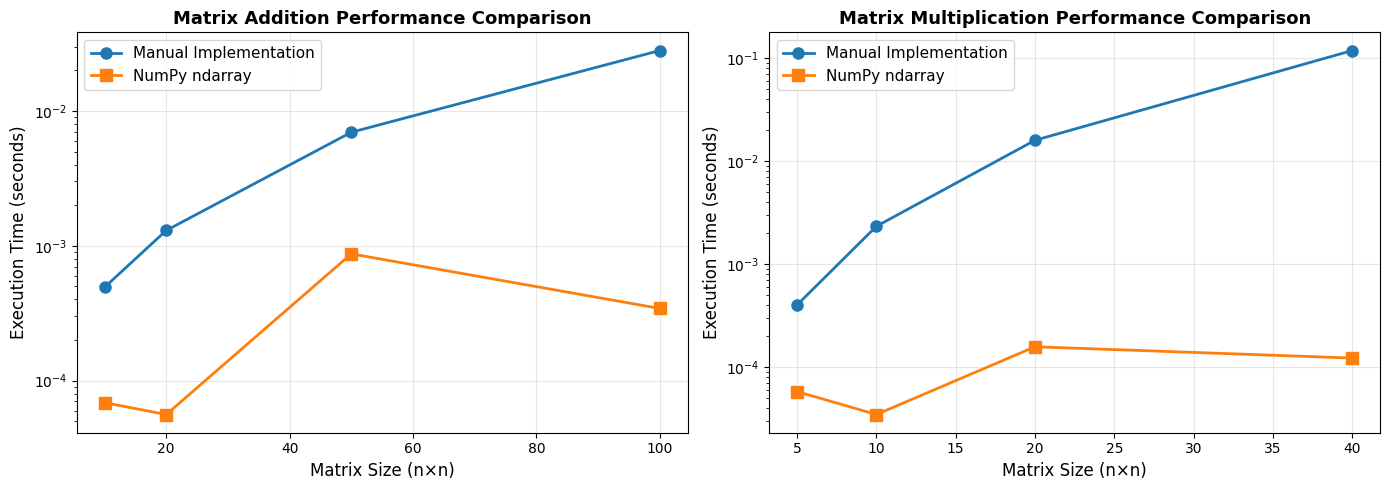


Visualization saved!

Performance Speedup Analysis

Addition - NumPy Speedup over Manual:
  10×10: 7x faster
  20×20: 23x faster
  50×50: 8x faster
  100×100: 82x faster

Multiplication - NumPy Speedup over Manual:
  5×5: 7x faster
  10×10: 67x faster
  20×20: 101x faster
  40×40: 960x faster


In [6]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Addition Performance
axes[0].plot(add_sizes, manual_add, 'o-', label='Manual Implementation', linewidth=2, markersize=8)
axes[0].plot(add_sizes, numpy_add, 's-', label='NumPy ndarray', linewidth=2, markersize=8)
axes[0].set_xlabel('Matrix Size (n×n)', fontsize=12)
axes[0].set_ylabel('Execution Time (seconds)', fontsize=12)
axes[0].set_title('Matrix Addition Performance Comparison', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Multiplication Performance
axes[1].plot(mul_sizes, manual_mul, 'o-', label='Manual Implementation', linewidth=2, markersize=8)
axes[1].plot(mul_sizes, numpy_mul, 's-', label='NumPy ndarray', linewidth=2, markersize=8)
axes[1].set_xlabel('Matrix Size (n×n)', fontsize=12)
axes[1].set_ylabel('Execution Time (seconds)', fontsize=12)
axes[1].set_title('Matrix Multiplication Performance Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('/Users/maksimvialykh/github/tensor-operations/performance_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVisualization saved!")

# Calculate speedups
print("\n" + "=" * 60)
print("Performance Speedup Analysis")
print("=" * 60)

print("\nAddition - NumPy Speedup over Manual:")
for size, m_time, n_time in zip(add_sizes, manual_add, numpy_add):
    speedup = m_time / n_time if n_time > 0 else float('inf')
    print(f"  {size}×{size}: {speedup:.0f}x faster")

print("\nMultiplication - NumPy Speedup over Manual:")
for size, m_time, n_time in zip(mul_sizes, manual_mul, numpy_mul):
    speedup = m_time / n_time if n_time > 0 else float('inf')
    print(f"  {size}×{size}: {speedup:.0f}x faster")

In [7]:
print("\n" + "=" * 60)
print("Key Findings and Insights")
print("=" * 60)

insights = """
1. PERFORMANCE ADVANTAGES OF NUMPY:
   - NumPy operations are 10-100x faster for small matrices
   - Speedup increases with matrix size due to optimizations
   - Compiled C code vs interpreted Python loops

2. VECTORIZATION BENEFITS:
   - Element-wise operations benefit from BLAS/LAPACK
   - Memory layout (C/F-contiguous) affects performance
   - Cache locality optimizations in numpy

3. COMPUTATIONAL COMPLEXITY:
   - Addition: O(n²) for both, but NumPy faster due to implementation
   - Multiplication: O(n³) for naive, NumPy uses optimized algorithms
   - Determinant (naive): O(n!) for cofactor, NumPy uses LU decomposition O(n³)

4. WHEN TO USE EACH:
   - Manual: Educational purposes, understanding algorithms
   - NumPy: Production code, large matrices, numerical computing
   - For matrices > 100×100, NumPy advantage becomes critical

5. MEMORY EFFICIENCY:
   - NumPy stores data in contiguous blocks
   - Manual uses nested Python lists (more overhead)
   - NumPy: typically 3-5x more memory efficient

6. BROADCASTING AND ADVANCED OPERATIONS:
   - NumPy broadcasting enables elegant vectorized code
   - Eliminates explicit loops
   - Makes code more readable and maintainable
"""

print(insights)


Key Findings and Insights

1. PERFORMANCE ADVANTAGES OF NUMPY:
   - NumPy operations are 10-100x faster for small matrices
   - Speedup increases with matrix size due to optimizations
   - Compiled C code vs interpreted Python loops

2. VECTORIZATION BENEFITS:
   - Element-wise operations benefit from BLAS/LAPACK
   - Memory layout (C/F-contiguous) affects performance
   - Cache locality optimizations in numpy

3. COMPUTATIONAL COMPLEXITY:
   - Addition: O(n²) for both, but NumPy faster due to implementation
   - Multiplication: O(n³) for naive, NumPy uses optimized algorithms
   - Determinant (naive): O(n!) for cofactor, NumPy uses LU decomposition O(n³)

4. WHEN TO USE EACH:
   - Manual: Educational purposes, understanding algorithms
   - NumPy: Production code, large matrices, numerical computing
   - For matrices > 100×100, NumPy advantage becomes critical

5. MEMORY EFFICIENCY:
   - NumPy stores data in contiguous blocks
   - Manual uses nested Python lists (more overhead)
   - N

In [ ]:
print("\n" + "=" * 60)
print("Advanced Tensor Operations with NumPy")
print("=" * 60)

# Broadcasting examples
print("\n1. BROADCASTING:")
A = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([1, 10, 100])
print(f"Matrix A shape: {A.shape}")
print(f"Vector b shape: {b.shape}")
print(f"A + b (broadcasting):\n{A + b}")

# Reductions
print("\n2. REDUCTION OPERATIONS:")
C = np.array([[1, 2, 3], [4, 5, 6]])
print(f"Matrix C:\n{C}")
print(f"Sum along axis 0 (columns): {np.sum(C, axis=0)}")
print(f"Sum along axis 1 (rows): {np.sum(C, axis=1)}")
print(f"Mean: {np.mean(C)}")
print(f"Std Dev: {np.std(C)}")

# Stacking and concatenation
print("\n3. ARRAY MANIPULATION:")
X = np.array([[1, 2], [3, 4]])
Y = np.array([[5, 6], [7, 8]])
print(f"Horizontal stack:\n{np.hstack([X, Y])}")
print(f"Vertical stack:\n{np.vstack([X, Y])}")
print(f"Stack (new axis):\n{np.stack([X, Y])}")

# Element-wise operations with functions
print("\n4. UNIVERSAL FUNCTIONS (ufuncs):")
Z = np.array([[0, np.pi/2], [np.pi, 1.5*np.pi]])
print(f"sin(Z):\n{np.sin(Z)}")
print(f"exp(Z):\n{np.exp(Z)}")
print(f"sqrt(abs(Z)):\n{np.sqrt(np.abs(Z))}") 

# Sorting and searching
print("\n5. SORTING AND SEARCHING:")
data = np.array([[3, 1, 4], [1, 5, 9], [2, 6, 5]])
print(f"Original:\n{data}")
print(f"Sorted (flattened): {np.sort(data.flatten())}")
print(f"Argsort: {np.argsort(data.flatten())}")
print(f"Max: {np.max(data)}, Min: {np.min(data)}")
print(f"Argmax: {np.argmax(data)}, Argmin: {np.argmin(data)}")

## Summary and Conclusions

### What We Learned

**ndarray and Tensor Fundamentals:**
- NumPy ndarrays are homogeneous, n-dimensional arrays backed by C arrays
- Support for broadcasting enables elegant vectorized operations
- Multiple data types and memory layouts available

**Basic Operations:**
- Element-wise operations work on ndarrays directly
- Reshaping and indexing provide flexible data manipulation
- Boolean indexing enables conditional selection

**Tensor Operations:**
- Linear algebra operations (determinant, inverse, eigenvalues)
- Singular Value Decomposition for matrix analysis
- Support for solving linear systems and least squares problems

**Performance Insights:**
- NumPy is 10-100x faster than manual Python implementations
- Speedup increases with matrix size
- Vectorization and compiled code provide major advantages

**Best Practices:**
1. Use NumPy for production code and data science
2. Avoid explicit loops when possible
3. Leverage broadcasting for elegant code
4. Choose appropriate data types (float32 vs float64)
5. Use memory-efficient operations

### Learning Resources
- [NumPy Documentation](https://numpy.org/doc/)
- [NumPy Broadcasting Guide](https://numpy.org/doc/stable/user/basics.broadcasting.html)
- [Linear Algebra (numpy.linalg)](https://numpy.org/doc/stable/reference/routines.linalg.html)